In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  #so that we can interact with our graghts and see the values
from sklearn.model_selection import train_test_split  #to split data
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression   #The model we want to use
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display #so that we can print the table more beautiful.(DataFrame)
#Instead of "print" we now use "display"


cars = pd.read_csv(r"C:\Users\HP\Desktop\CODE ALPHA\archive\car data.csv")
display(cars)
display(cars.info())
display(cars.describe())
cars = cars.dropna()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


None

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [250]:
selling_price = px.histogram(cars, x = 'Selling_Price', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()

In [251]:
selling_price = px.histogram(cars,x= 'Year' , y = 'Selling_Price', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()  #shows that cars of latest years cost more.

In [252]:
cars.Selling_Price.corr(cars.Year)

np.float64(0.23614098016042726)

In [253]:
selling_price = px.histogram(cars, y= 'Selling_Price', x = 'Driven_kms', marginal = 'box', title = 'Mileage', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()

We can see that Cars with lower mileage, has higher prices

In [254]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cars['mileage'] = scaler.fit_transform(cars[['Driven_kms']])  # squishes values to 0-1 range

In [226]:
print(cars.Selling_Price.corr(cars.Driven_kms))
print(cars.Selling_Price.corr(cars.mileage))

0.029187090674291257
0.029187090674291306


it doesnt really affect the correllation, but it just shrinks the values so we can use it to predick the selling price which are all small

In [227]:
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876


In [228]:
selling_price = px.histogram(cars, y= 'Selling_Price', x = 'mileage', marginal = 'box', title = 'Mileage', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()

In [229]:
cars.Selling_Price.corr(cars.mileage)

np.float64(0.029187090674291306)

In [230]:
selling_price = px.histogram(cars, x = 'Selling_Price', marginal = 'box', color= 'Fuel_Type', color_discrete_sequence = ['red', 'green', 'grey'], title = 'Fuel type & Present Price', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
#color will color a particular grapgh using two categories from a colum that contains E.g. Yes/No
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()

HOTCODING CATEGORICAL VARIABLES MANUALLY

In [231]:
fuels = px.histogram(cars, x = 'Fuel_Type' , y = 'Selling_Price')
fuels.show()

Rule of thumb: Only use integer encoding for truly ordinal data (e.g., low=0, medium=1, high=2) <br> where the order actually means something. For nominal categories like fuel type, brand, or color, <br> always one-hot encode.

In [255]:
from sklearn import preprocessing
encoder = preprocessing.OneHotEncoder()
encoder.fit(cars[['Fuel_Type']])
fuel_encoded = encoder.transform(cars[['Fuel_Type']]).toarray()  #adding 'toarray()' is important
display(fuel_encoded)

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0

This is not yet part of the dataframe, so we now add it <br>
if you used Petrol, diesel, CNG. you will get different column value from <br>
CNG, Diesel, Petrol. <br>

So, Comparing it with the old Data to see that where Petrol appear is 1

In [256]:
cars[['CNG', 'Diesel', 'Petrol']] = fuel_encoded  #arrangement of how you name the column is important
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,CNG,Diesel,Petrol
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0


In [234]:
print(cars.Selling_Price.corr(cars.Petrol))
print(cars.Selling_Price.corr(cars.Diesel))
print(cars.Selling_Price.corr(cars.CNG))

-0.5405710829430346
0.5523392892828558
-0.025164202641276456


Thats why you notices that, number of cars that use petrol reduces as price increases

In [235]:
selling_price = px.histogram(cars, y = 'Selling_Price', x = 'Fuel_Type', marginal = 'box', color= 'Transmission', color_discrete_sequence = ['red', 'green'], title = 'Fuel type & Present Price', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
#color will color a particular grapgh using two categories from a colum that contains E.g. Yes/No
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()

In [236]:
present_price = px.violin(cars, y = 'Selling_Price', x = 'Petrol', color= 'Fuel_Type', title = 'Selling Price & Present Price') #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
#color will color a particular grapgh using two categories from a colum that contains E.g. Yes/No
#scatter will help show if there is a correlation between the two data. (selection of the test data vs the target data)
present_price.show()   #but we can use this feature to train the model cus its just too easy to predict

In [237]:
cars['Selling_type'].value_counts()

Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

In [257]:
from sklearn import preprocessing
encoder = preprocessing.OneHotEncoder()
encoder.fit(cars[['Selling_type']])
dealer_encoded = encoder.transform(cars[['Selling_type']]).toarray()  #adding 'toarray()' is important
#display(dealer_encoded)---- not neccessary to display it

cars[['Dealer', 'Individual']] = dealer_encoded  #arrangement of how you name the column is important
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0


In [239]:
print(cars.Selling_Price.corr(cars.Individual))
print(cars.Selling_Price.corr(cars.Dealer))


-0.550723761577876
0.550723761577876


Individual has a negative correllation becuase, Buying a Car from an individual e.g A friend <br>
is Way cheaper than buying from  a Dealer

To visualize this, we can use either the individual Column, or the Dealer Column <br>
but take note that<br> <b>Individual = 1,<br> Dealer = 0,<br> <b>if we use the Individual column <b>

In [240]:
present_price = px.violin(cars, y = 'Selling_Price', x = 'Individual', title = '(Individual = 1, Dealer = 0) vs Selling Price') 
present_price.show()


In [241]:
present_price = px.histogram(cars, y = 'Selling_Price', x = 'Year', color= 'Selling_type', title = 'Year vs Selling Price') 
present_price.show()

In [242]:
cars.Selling_Price.corr(cars.Year)

np.float64(0.23614098016042726)

THIS corr Method use the check the relationship (Correlation) between our target and our input data. this determines which column we use when building the model

In [243]:
cars.Present_Price.corr(cars.Selling_Price)

np.float64(0.8789144098187837)

In [244]:
cars.Selling_Price.corr(cars.Owner)

np.float64(-0.08834409908720235)

To compute the correlation for categorical data/columns (e.g. Yes/No) they must first be hotcoded/converted to numeric columns and give them seperate column for clarity

In [258]:
from sklearn import preprocessing
encoder = preprocessing.OneHotEncoder()
encoder.fit(cars[['Transmission']])
column_encoded = encoder.transform(cars[['Transmission']]).toarray()  #adding 'toarray()' is important
#display(dealer_encoded)---- not neccessary to display it

#this will now add it to the dataframe
cars[['Automatic', 'Manual']] = column_encoded  #arrangement of how you name the column is important
display(cars)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [246]:
print(cars.Present_Price.corr(cars.Manual))
print(cars.Present_Price.corr(cars.Automatic))

-0.3487764971028124
0.3487764971028122


Encoding the brand name will just make the dataset complex, so i will leave it


....Checkpoint

In [247]:
display(cars.Car_Name.value_counts())

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               11
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64

To check the Categories in a column 

In [259]:
cars.corr() # will give you a correlation matrix which is often visualized using a heatmap, give error becuause  all the columns are not numeric

ValueError: could not convert string to float: 'ritz'

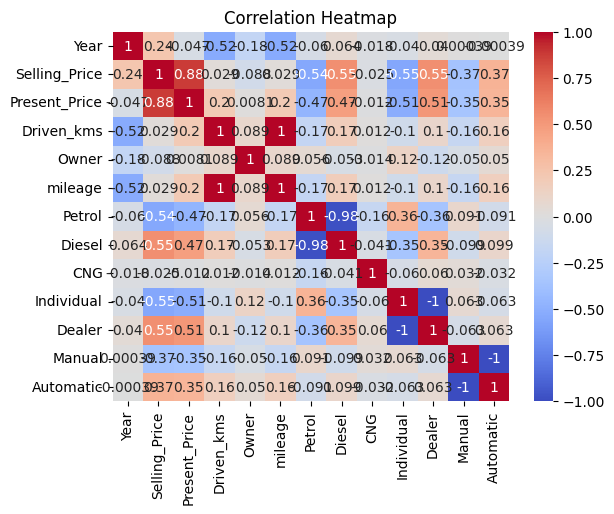

In [ ]:
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm')  #cars.corr(numeric_only=True) makes sure to select just columns that have numeric data
plt.title('Correlation Heatmap')
plt.show()

WE CAN NOW GO INTO FEATURE ENGINEERING

In [260]:
cars['Car_Age'] = 2026 - cars['Year']  #Newer cars usually cost more
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0,9


In [262]:
cars.Selling_Price.corr(cars.Car_Age) #in  real world, car the year a car was produced is very crucial. 

np.float64(-0.2361409801604276)

the higher the age, the lower the price, thats why, newer cars cost more thats why we have a -ve correlation

LET ME TRANSFORM THE MILEAGE AGAIN USING LOG

In [ ]:
present_price = px.histogram(cars, x = 'Driven_kms', title = 'Year vs Selling Price') 
present_price.show()

**Why Log over StandardScaler for this data:**

Your `Driven_kms` feature was heavily right-skewed, with most cars clustered between `0-100k` but a few outliers stretching all the way to `500k`. StandardScaler only rescales the data — it does not change its shape, meaning those extreme outliers at `300k-500k` would still distort the distribution and pull the model's attention away from where most of your data actually lives. Log transform on the other hand compresses large values aggressively while spreading out the dense cluster, fundamentally reshaping the distribution into the bell curve you now see between `6-13`. A bell-shaped distribution is what machine learning models thrive on because the data is evenly spread with no single extreme value dominating the learning process. The result speaks for itself — your histogram went from a long-tailed skew to a near-perfect bell, which means your model now has a much fairer and more balanced view of the feature.

np.log() does the same thing as pressing the 'Ln' button on your calculator for each value

In [263]:
fstinput = np.log(cars[['Driven_kms']])
cars['mileage_log'] = np.log(cars['Driven_kms'])
display(cars)  # after - should look like a bell curve

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980


In [ ]:
print(cars.Selling_Price.corr(cars.mileage))
print(cars.Selling_Price.corr(cars.mileage_log))

0.029187090674291306
0.1251925615550675


NOTE: <b> I will use mileage_log since it has a higer correlation <b>

**Because machine learning models are bad at handling extreme gaps in numbers.**

Think of it this way — imagine you're teaching a student to spot patterns in these numbers:

```
1,000
5,000
10,000
500,000  ← this one number dominates everything
```

The student's eyes keep getting drawn to `500,000` and ignoring the rest. That's exactly what happens to a model — it gets **distracted by the big numbers** and struggles to learn from the smaller ones.

After log transform:
```
6.9
8.5
9.2
13.1  ← no longer screaming for attention
```

Now all values are in a **similar range** and the model can learn from all of them fairly.

**In practical terms for your car data:**

- Without log → the model thinks a car that drove `500k km` is incomparably different from one that drove `50k km`
- With log → the model understands it as just a **proportional difference**, which reflects reality better

**The 3 main reasons to do it:**

1. **Fairness** — no single value dominates the learning
2. **Better predictions** — model sees patterns more clearly
3. **Lower RMSE** — your error score improves because predictions are more accurate

It's essentially **translating your data into a language the model understands better.**

In [ ]:
mileage_log = px.histogram(cars, x = 'mileage_log' ) 
mileage_log.show()

CHECK OUT THE DIFFERENCE

In [ ]:
mileage_log = px.histogram(cars, x = 'mileage' ) 
mileage_log.show()

Using Selling Price Correlation is like telling the maching the answer.



.....Checkpoint

In [ ]:
cars.Selling_Price.corr(cars.mileage_log)

np.float64(0.1251925615550675)

Whatever transformation you did to your training data, you must do the same to any new input before prediction. 

```python
import numpy as np

# User inputs raw mileage
new_car_mileage = 45000

# Must convert to log first before feeding to model
new_car_mileage_log = np.log(new_car_mileage)

# Now feed to model
predicted_price = model.predict([[new_car_mileage_log]])
```

**Think of it like a language rule:**
- You trained your model speaking **"log language"**
- If you feed it raw numbers, it's like speaking **English to someone you trained in French** — the answer will be wrong or nonsensical

**A clean way to handle this is to wrap it in a function:**

```python
def predict_price(mileage):
    mileage_log = np.log(mileage)  # 👈 convert first
    predicted = model.predict([[mileage_log]])
    return predicted

# Now anyone can just pass raw mileage and not worry about log
predict_price(45000)
predict_price(120000)
```

This way the log conversion happens **automatically inside the function** and whoever uses your model doesn't have to remember to convert manually — the function handles it for them.

ACTUALLY, I WILL NOW GO ON WITH SELLING PRICE BECAUSE
SELLING PRICE: IS THE PRICE THE CAR WAS SOLD AFTER USAGE AND MILAGE AND ALL
PRESENT PRICE: IS JUST THE PRICE OF THE CAR NOW IN THE SHOWROOM (BRANDNEW)
its like buying/selling uk used laptop. 

the question will be, 
given those Mileage, owner, year, how much i will buy it brandnew(Present price) and all, what will be the price i can sell the car now

Difference (Selling – Present): 
Good for understanding how much money is lost.

Ratio (Selling ÷ Present):
Good for comparing across cars of different price brackets (a luxury car losing 10 lakh vs. a budget car losing 2 lakh — ratio tells you which depreciates faster).

In practice, the ratio is often more predictive in resale models, because it scales across price ranges. But including both can give your regression model richer signals

but they will only result in Data Leakage

Car A → 100,000 km over 20 years = 5,000 km/yr  ← lightly used <br>
Car B → 100,000 km over 4 years  = 25,000 km/yr ← heavily used

Car Age:
Age is one of the strongest predictors of depreciation.

Depreciation Ratio:
shows how much value the car has retained.

Kilometers per Year:

Normalizes mileage by age because the price of a car driven 100,000 km in 2 years is very different from 100,000 km in 10 years.

In [ ]:
cars['Owner'].value_counts()

Owner
0    290
1     10
3      1
Name: count, dtype: int64

In [ ]:
cars.Selling_Price.corr(cars.Owner)

np.float64(-0.08834409908720235)

FEATURE ENGINEERING SECTION (Additional columns/information)

In [264]:
from datetime import datetime

current_year = datetime.now().year #better than Harding coding 2026, cus every new year, the prediction becomes wrong
cars['Car_Age'] = current_year - cars['Year']

cars['Driven_kms_log'] = np.log1p(cars['Driven_kms'])
cars['car_useage'] = (cars['Driven_kms_log'])/(cars['Car_Age'])
#Calculated the depreciation of the car shows how much value the car has retained
from sklearn.preprocessing import StandardScaler
import pandas as pd

display(cars)



,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,...,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,Driven_kms_log,car_useage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,...,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592,10.203629,0.850302
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,...,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955,10.668979,0.820691
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,...,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277,8.839422,0.982158
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,...,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414,8.556606,0.570440
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,...,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082,10.656106,0.888009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,...,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763,10.433792,1.043379
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,...,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100,11.002117,1.000192
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,...,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342,11.384353,0.669668
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,...,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980,9.105091,1.011677


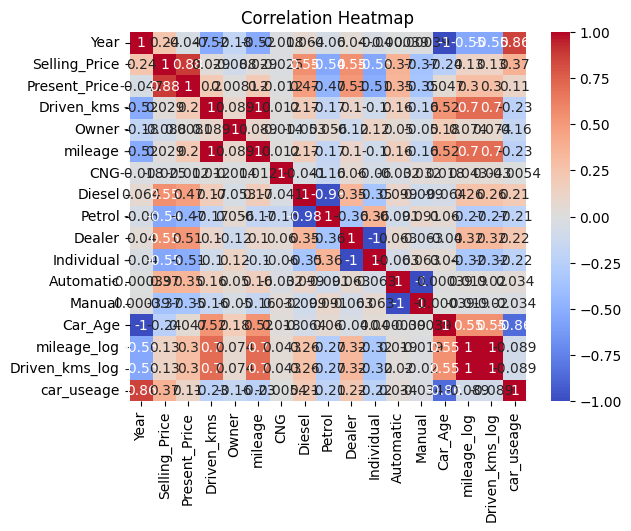

In [ ]:
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
px.scatter(cars, y = 'Selling_Price', x = 'car_useage')

MODEL RECOMMENDATION
Begin with Linear Regression for baseline. Y = MX + C (equation of a straigh line)

Then test RANDOM FOREST and XGBOOST
they usually outperform linear models for car price prediction.

Evaluate using R², MAE, and RMSE to compare.

<2> If Nonlinear Patterns Exist (as your plot suggests)
Try nonlinear or ensemble models that handle complex relationships:

Polynomial Regression (adds squared or cubic terms)

Random Forest Regressor — captures nonlinear interactions automatically.

XGBoost or LightGBM — excellent for tabular data with mixed feature types.

Gradient Boosting Regressor — balances bias and variance well.

So we will use 

Selling Price = M x drivenKm_Age + c

In [265]:
def est_price (estprice, m, c ):   #def is used to define our model
    return m*estprice + c 
m = 2
c = 1            #this is our first model formular (but it also what LinearRegression does)
estprice = cars['car_useage']       #we now use our desires column here
estimated_price = est_price(estprice, m,c)
display(estimated_price)
    

0      2.700605
1      2.641381
2      2.964316
3      2.140881
4      2.776018
         ...   
296    3.086758
297    3.000385
298    2.339336
299    3.023354
300    2.721224
Name: car_useage, Length: 301, dtype: float64

CheckPoint

In [ ]:
display(cars['Selling_Price']) #juat to compare with the actual selling price

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [ ]:
px.scatter(cars, y = estimated_price, x = 'car_useage')  #they have a linear relationship.

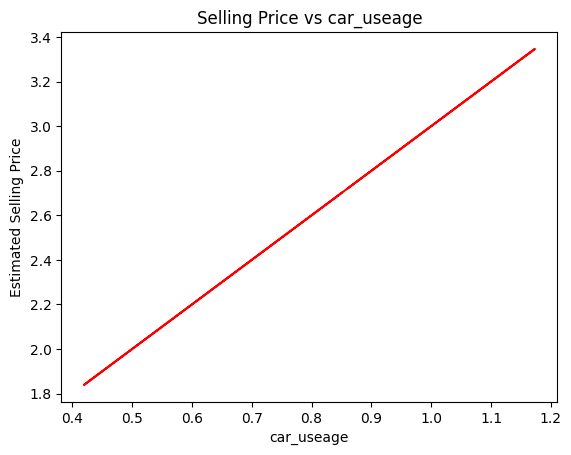

In [266]:
import matplotlib.pyplot as plt

# Assuming you already have these columns in your DataFrame
x = cars['car_useage']      # numeric column
y = estimated_price                  # predicted or target values

plt.plot(x, y, 'r-')   
px.scatter(cars, y = 'Selling_Price', x = 'car_useage')
plt.xlabel('car_useage')
plt.ylabel('Estimated Selling Price')
plt.title('Selling Price vs car_useage')
plt.show()


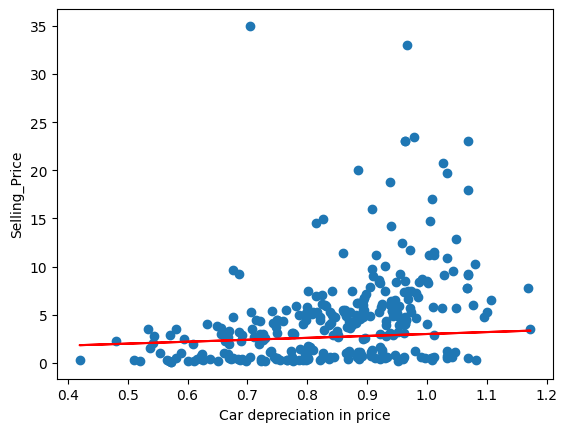

In [ ]:
#target = pd.DataFrame(cars['Selling_Price']) #this is how to convert a single column to a dataframe and work with it
plt.plot(cars['car_useage'], estimated_price , 'r-')
plt.scatter(cars['car_useage'], cars['Selling_Price'])
plt.xlabel('Car depreciation in price')
plt.ylabel('Selling_Price')
plt.show()

LETS GET A FUNCTION THAT WE CAN USE TO TRY DIFFERENT VALUES OF 'M' AND 'C'

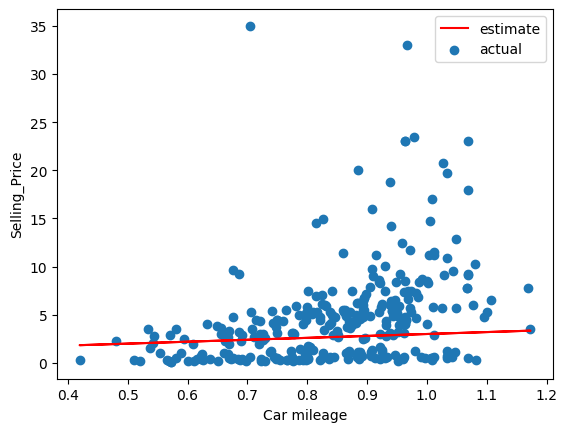

,Predicted,Actual
0,2.700605,3.35
1,2.641381,4.75
2,2.964316,7.25
3,2.140881,2.85
4,2.776018,4.60
...,...,...
296,3.086758,9.50
297,3.000385,4.00
298,2.339336,3.35
299,3.023354,11.50


In [267]:
estprice = cars['car_useage']

#you can use this function to manually try and fit the line of regression

def try_price(m, c):
    def est_price(estprice, m, c):
        return m * estprice + c

    estimated_price = est_price(estprice, m, c)

    plt.plot(cars['car_useage'], estimated_price, 'r-')
    plt.scatter(cars['car_useage'], cars['Selling_Price'])
    plt.xlabel('Car mileage')
    plt.ylabel('Selling_Price')
    plt.legend(['estimate', 'actual'])
    plt.show()
    return estimated_price
target = cars['Selling_Price']
comparison = try_price(2,1)   #change the values of try(2,1) to see how close you get to the actual price
forecast = pd.DataFrame({'Predicted': comparison, 'Actual': target}) #The fix is to build the DataFrame from a dict mapping column names to your two series. 
display(forecast)
 

CALCULATE LOSS/COST FUNCTIONS

We will now compare our estimate with the actual selling price using the Root Mean Square Error (RMSE)

RMSE (Root Mean Square Error) is used to measure how far off your model's predictions are from the actual values.
Absolut values '|predicted - actual|' can be takes too.
NOTE that Outliers have a bigger effect on Square method more than Abosolute Methods because if the gap is too much, the square will also be bigger. However, absolute values just ignores the -ve sign. 

E.g.  (4- 9) gives -5. Which means the Square is 25. But Abosolute value just leave it at 5

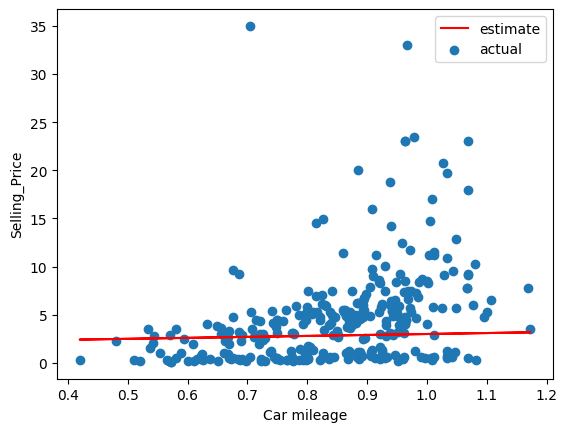

np.float64(5.341174913957651)

In [268]:
target = cars['Selling_Price']
predictions = try_price(1,2)   #from the 'rmse result' (1,2) is better than (2,1)
def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))


rmse (target, predictions)

TAKE NOTE OF THIS WHEN WORKING WITH MILAGE AND OTHER BIG NUMBERS

your `m` value will have to be very small to compensate. Here's why:

**Your formula is:**
```
estimated_price = m * estprice + c
```

If `estprice` is `1000+` and you want output between `3-20`, then `m` needs to be tiny to scale it down, for example:

```
m = 0.001, c = 2
→ 0.001 * 1000 + 2 = 3      ✅
→ 0.001 * 5000 + 2 = 7      ✅
→ 0.001 * 18000 + 2 = 20    ✅
```

**The real problem though** is that finding the right `m` by trial and error becomes very hard because:
- A tiny change in `m` (e.g. `0.001` → `0.002`) causes a huge swing in predictions
- It makes tuning very frustrating

**The proper fix is to scale your feature first:**

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
estprice = scaler.fit_transform(cars[['Car_depre_price']])  # squishes values to 0-1 range
```

Now your feature is between `0` and `1`, so your `m` and `c` values become much more intuitive to tune and your predictions in the `3-20` range are easier to dial in.

**In short:**
- Mathematically it still works ✅
- But practically, scaling your feature first makes life much easier ✅

In [269]:
model = LinearRegression()   #this is where you define what kind of model you want and what the relationship is
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [270]:
fstinput = cars[['car_useage']]  #cars[] will give me 1D, remember that 'mosel.fit' need 2D so use cars[[]]
target = cars['Selling_Price'] #this one can be left as 1D
display(fstinput.shape, target.shape)


(301, 1)

(301,)

In [271]:
model = LinearRegression() 
model.fit(fstinput, target)  #we could have also said LinearRegression.fit(), but we already assinged model= LinearRegression()
#'fit' here will help us determine the best slope 'm' and y-intercept'c' of out regression line.
#it will continue to do all those (2,1) changing and calculate RMSE and give me the result

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


So, now we can predict the prices for any car if we know its 

THIS IS BASICALLY THE PRICTION USER INTERFACE <br>
Because it allows you predict the price of any car, given the "year","mileage" and "the type of seller (dealer/owner)"

In [272]:
import numpy as np
from datetime import datetime

# Collect user input
driven_kms = float(input("Enter the mileage of the car: "))
year = int(input("Enter the year the car was manufactured: "))


# Calculate derived features
current_year = datetime.now().year
car_age = current_year - year

# Avoid division by zero
if car_age == 0:
    car_age = 1

car_mileage = np.log1p(driven_kms)
car_usage = car_mileage / car_age

# Combine features into a NumPy array
inputsdata = np.array([[car_usage]])

# Predict using your trained model
prediction = model.predict(inputsdata)
print("Predicted value:", prediction)

rmse (target, predictions)


ValueError: could not convert string to float: ''

In [ ]:
model.intercept_

np.float64(-6.550065773815092)

scikit‑learn’s `LinearRegression()` implements the classic linear model, which in its simplest form is the familiar equation:

\[
y = m x + c
\]

where:
- \(y\) = predicted output (target variable)  
- \(x\) = input feature (independent variable)  
- \(m\) = slope (coefficient)  
- \(c\) = intercept (bias term)

---

### But here’s the important detail:
- If you have **one feature**, it’s literally \(y = m x + c\).  
- If you have **multiple features**, it generalizes to:

\[
y = x0+ Kx_1 + Kx_2 + ... + Kx_n
\]

where \(x0) is the intercept and each \(\Xn\) is a coefficient for feature \(K).


👉 In practice, after fitting your model with `model.fit(X, y)`, you can inspect the learned parameters:

```python
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
```

That will show you the actual \(c\) and \(m\) values (or multiple slopes if you have more than one feature).

---

Would you like me to show you how to **interpret those coefficients** in the context of your car dataset — e.g., how much the price changes per unit increase in mileage or seller type?

In [273]:


feature = cars[['car_useage']]

# Combine features into a NumPy array
inputsdata = feature
# Predict using your trained model
prediction = model.predict(inputsdata)
print("Predicted value:", prediction)

Predicted value: [ 4.71414633  4.32187035  6.46087613  1.00672998  5.2136541   6.0949293
  5.30199628  5.99537978  6.58740771  6.28072623  4.7347066   6.50406594
  5.03032977  5.69271665  2.22206598  7.58345119  6.26098058  7.58345119
  6.06776684  2.25282711  6.86504007  4.9068485   3.00547574  5.28489924
  4.60691193  2.19627697  4.57523405  7.7170244   2.31255259  6.35333511
  3.71486204  3.07670767  5.12008048  5.2780517   5.2780517   3.00544041
  6.45014837  0.21870032  5.66170486 -0.19429549  6.83957502  5.31912864
  1.52211482  5.29702233  3.68801442  4.06529681  4.73554621  0.79036822
  5.68668027  8.93264379  4.38740805  6.21149233  7.603751    5.48769276
  0.64610526  2.14348693  6.22746297  2.40825439  5.13372398  5.17528769
  4.24820118  6.22906625  5.88526043  6.40570309  6.2551894   5.2780517
  7.14726272  2.54529059  3.50472692  5.89278642  5.78145934  2.91242821
  4.59105961  2.87227887  5.95384944  6.08461     4.84713259  0.56384168
  2.79739065  4.23361832  6.75458655

In [ ]:
cars['Selling_Price']

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [ ]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print(prediction.reshape(-1, 1))

Coefficient: [13.24730082]
Intercept: -6.550065773815092
[[ 4.71414633]
 [ 4.32187035]
 [ 6.46087613]
 [ 1.00672998]
 [ 5.2136541 ]
 [ 6.0949293 ]
 [ 5.30199628]
 [ 5.99537978]
 [ 6.58740771]
 [ 6.28072623]
 [ 4.7347066 ]
 [ 6.50406594]
 [ 5.03032977]
 [ 5.69271665]
 [ 2.22206598]
 [ 7.58345119]
 [ 6.26098058]
 [ 7.58345119]
 [ 6.06776684]
 [ 2.25282711]
 [ 6.86504007]
 [ 4.9068485 ]
 [ 3.00547574]
 [ 5.28489924]
 [ 4.60691193]
 [ 2.19627697]
 [ 4.57523405]
 [ 7.7170244 ]
 [ 2.31255259]
 [ 6.35333511]
 [ 3.71486204]
 [ 3.07670767]
 [ 5.12008048]
 [ 5.2780517 ]
 [ 5.2780517 ]
 [ 3.00544041]
 [ 6.45014837]
 [ 0.21870032]
 [ 5.66170486]
 [-0.19429549]
 [ 6.83957502]
 [ 5.31912864]
 [ 1.52211482]
 [ 5.29702233]
 [ 3.68801442]
 [ 4.06529681]
 [ 4.73554621]
 [ 0.79036822]
 [ 5.68668027]
 [ 8.93264379]
 [ 4.38740805]
 [ 6.21149233]
 [ 7.603751  ]
 [ 5.48769276]
 [ 0.64610526]
 [ 2.14348693]
 [ 6.22746297]
 [ 2.40825439]
 [ 5.13372398]
 [ 5.17528769]
 [ 4.24820118]
 [ 6.22906625]
 [ 5.88526043

So -1 is just a shortcut that adapts to whatever length your array has. If tomorrow you had 100 <br> predictions, reshape(-1, 1) would give (100, 1) without you needing to change the code.<br>

Why not just 1?<br>
If you wrote reshape(1, 1), NumPy would force the array into exactly 1 row and 1 column, which only <br>
works if your array has exactly 1 element. For 50 elements, it would throw an error because the <br>sizes don’t match.

In [274]:
rmse(target, prediction)  #this is the RMSE loss of our model. 
#which is better, compared to the RMSE loss of (1,2) above, which was 5.341174913957651

np.float64(4.71201545134882)

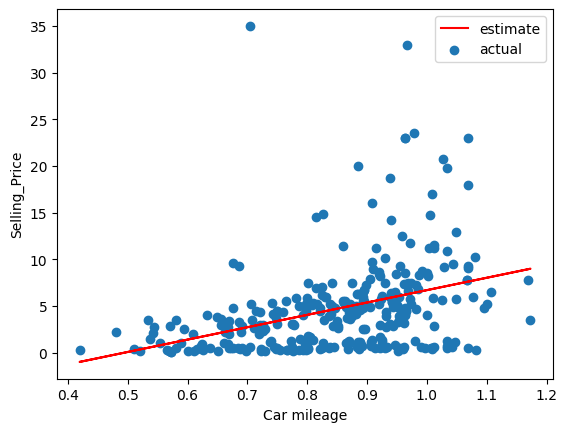

np.float64(4.712015451348819)

In [279]:
target = cars['Selling_Price']
try_predict = try_price(13.24730082,-6.550065773815092)   #we can now try the values our model used and also visualize the line
def rmse (target, try_predict):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - try_predict)))


rmse (target, try_predict)

But here’s the important detail:
If you have one feature, it’s literally 
𝑦 = 𝑚𝑥 + 𝑐 . <br>
If you have multiple features, it generalizes to:<br>

𝑦 = c + 𝛽b + 𝛽c + ⋯ + 𝛽𝑛
where 
c is the intercept and each 

𝛽
 is a coefficient for feature 
n
So in your car price model, if you’re using two features (like car_usage and seller_type), the formula looks like:

Price = c + 𝛽⋅car_usage + 𝛽⋅seller_type

SUMMARY <BR>
Training = model.fit(X, y) → learns from your dataset.   X = cars[['car_useage', 'Fuel_Type']]<br>

Prediction = model.predict(new_data) → uses what it learned to estimate new outcomes.

In [276]:
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,...,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,Driven_kms_log,car_useage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,...,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592,10.203629,0.850302
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,...,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955,10.668979,0.820691
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,...,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277,8.839422,0.982158
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,...,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414,8.556606,0.570440
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,...,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082,10.656106,0.888009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,...,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763,10.433792,1.043379
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,...,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100,11.002117,1.000192
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,...,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342,11.384353,0.669668
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,...,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980,9.105091,1.011677


check point

In [282]:
import numpy as np
from sklearn.metrics import mean_squared_error
from datetime import datetime

features = cars[['car_useage', 'Diesel', 'Individual','Dealer','Manual','Automatic','Car_Age']]  #Added one more Feature
#That’s 7 columns. So, during prediction, you must supply all 7 values in the same order.
target = cars['Selling_Price'] 


model = LinearRegression() 
model.fit(features, target)  #(x,y) trains the model with the selected features.

# Collect user input
driven_kms = float(input("Enter the mileage of your car: "))
year = int(input("Enter the year your car was manufactured: "))

# Fuel type
fuel_type = input("Enter fuel type (Diesel/Petrol): ").strip().lower()
diesel = 1 if fuel_type == "diesel" else 0

# Seller type
seller_type = input("Enter seller type (Individual/Dealer): ").strip().lower()
individual = 1 if seller_type == "individual" else 0
dealer = 1 if seller_type == "dealer" else 0
#important because dealer collect thier commission campared to buying it from the owner of the car directly

# Transmission type
transmission = input("Enter transmission type (Manual/Automatic): ").strip().lower()
manual = 1 if transmission == "manual" else 0
automatic = 1 if transmission == "automatic" else 0

# Calculate car age
current_year = datetime.now().year
car_age = current_year - year
if car_age == 0:
    car_age = 1

# Compute car usage
car_mileage = np.log1p(driven_kms)
car_usage = car_mileage / car_age

# Combine features into a NumPy array
inputsdata = np.array([[car_usage, diesel, individual, dealer, manual, automatic, car_age]])

# Predict using your trained model
prediction = model.predict(inputsdata)
print("Predicted value:", prediction)



target = cars['Selling_Price']
def rmse (target, predicted):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predicted)))
print(rmse(target, prediction))  #sometimes, the more the feature, the harder it becomes


overall_rmse = np.sqrt(mean_squared_error(target, model.predict(features)))
#That gives you the average deviation across your dataset.
print("Overall RMSE:", overall_rmse)



Predicted value: [5.45035723]
5.135344289311494
Overall RMSE: 3.2732086304662893


c:\Users\HP\Desktop\VS CODE FOLDERS\test environment.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Each column (Individual, Dealer, Manual, Automatic) is one-hot encoded — meaning:<br>

1.0 indicates the presence of that category.<br>

0.0 indicates absence.

In [ ]:
cars[['Car_Age', 'car_useage']].corr()

,Car_Age,car_useage
Car_Age,1.000000,-0.857538
car_useage,-0.857538,1.000000


In [ ]:

display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,mileage,...,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,Driven_kms_log,car_useage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,...,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592,10.203629,0.850302
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,...,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955,10.668979,0.820691
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,...,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277,8.839422,0.982158
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,...,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414,8.556606,0.570440
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,...,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082,10.656106,0.888009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,...,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763,10.433792,1.043379
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,...,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100,11.002117,1.000192
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,...,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342,11.384353,0.669668
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,...,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980,9.105091,1.011677
